In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -qU ultralytics supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.6/273.6 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 10.6 MB/s eta 0:00:00


In [57]:
from ultralytics import YOLO
import cv2
import os
import numpy as numpy
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
from tqdm import tqdm
import shutil

In [ ]:
!nvidia-smi

Thu Jun 18 12:52:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##Load Dataset

In [ ]:
import os
# HOME = os.getcwd()
HOME = ('/content/drive/MyDrive/purwadhika/Module 4/capstone4')

os.chdir(HOME)

In [ ]:
dataset_location = "./vehicle-detection.v1i.yolov12"

In [ ]:
!ls {dataset_location}

data2.yaml  README.dataset.txt	 test	valid
data.yaml   README.roboflow.txt  train


In [ ]:
!cat {dataset_location}/data2.yaml

train: ../preprocessing
val: ./valid/images
test: ./test/images

nc: 3
names: ['bus', 'car', 'van']

roboflow:
  workspace: personal-project-kej16
  project: vehicle-detection-vznzd-dkl8g
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/personal-project-kej16/vehicle-detection-vznzd-dkl8g/dataset/1

##Preprocessing Data

In [58]:
print("load data image")
folder_image = "./vehicle-detection.v1i.yolov12/train/images"
folder_label = "./vehicle-detection.v1i.yolov12/train/labels"
output_images = "./preprocessing/images"
output_labels = "./preprocessing/labels"
os.makedirs(output_images, exist_ok=True)
os.makedirs(output_labels, exist_ok=True)
print("preprocessing data")
total = 0
for img_name in tqdm(os.listdir(folder_image)):
    path_image = os.path.join(folder_image, img_name)
    image = cv2.imread(path_image)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(image_rgb, (int(image_rgb.shape[0]/2), (int(image_rgb.shape[1]/2))))

    save_path = os.path.join(output_images, img_name)
    cv2.imwrite(save_path, resized)

    label_name = os.path.splitext(img_name)[0] + ".txt"
    src_label = os.path.join(folder_label, label_name)
    dst_label = os.path.join(output_labels, label_name)

    if os.path.exists(src_label):
        shutil.copy(src_label, dst_label)
print("Selesai menyimpan preprocessing semua gambar.")

load data image
preprocessing data


100%|██████████| 8380/8380 [49:23<00:00,  2.83it/s]

Selesai menyimpan preprocessing semua gambar.


##Pretraining Model

In [ ]:
!wget https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt

--2026-06-17 19:02:44--  https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/928546208/99db71db-0946-4c10-94a0-b54baf471037?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-17T20%3A01%3A32Z&rscd=attachment%3B+filename%3Dyolov12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-17T19%3A01%3A29Z&ske=2026-06-17T20%3A01%3A32Z&sks=b&skv=2018-11-09&sig=1ixaW6QuLq4iVBNm%2FWEPpONE8UED4Vf6xQ7wRULi3%2Fw%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MTcyMzI2NCwibmJmIjoxNzgxNzIyOTY0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLm

In [62]:
len(os.listdir("./preprocessing/images"))

8380

In [63]:
!cat "./vehicle-detection.v1i.yolov12/data2.yaml"

train: ../preprocessing/images
val: ./valid/images
test: ./test/images

nc: 3
names: ['bus', 'car', 'van']

roboflow:
  workspace: personal-project-kej16
  project: vehicle-detection-vznzd-dkl8g
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/personal-project-kej16/vehicle-detection-vznzd-dkl8g/dataset/1

In [64]:
model_name = "yolov12n.pt"

In [77]:
model = YOLO(model_name)
results = model.train(
    data="./vehicle-detection.v1i.yolov12/data2.yaml",
    epochs=20,
    batch=16,
    exist_ok=True,
    patience=5,
    save_period=2,
    val=True,
    verbose=True
)
print("selesai print model")

New https://pypi.org/project/ultralytics/8.4.71 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./vehicle-detection.v1i.yolov12/data2.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scal

In [ ]:
# model = YOLO("./runs/detect/train/weights/best.pt")

In [82]:
metrics = model.val()

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.9±0.4 ms, read: 32.5±21.4 MB/s, size: 72.3 KB)
val: Scanning /content/drive/MyDrive/purwadhika/Module 4/capstone4/vehicle-detection.v1i.yolov12/valid/labels.cache... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 66.9Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 19, len(boxes) = 427. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 2.3it/s 7.9s
                   all        287        427      0.782      0.783      0.802      0.614
                   bus         67        113      0.935      0.769      0.876      0.631
                   car        211        279      0.868      0

In [83]:
print(metrics.box.map)
print(metrics.box.map50)
print(metrics.box.map75)

0.613582766879795
0.8018107911146304
0.6972792103490777


In [78]:
results = model("./street.jpg")


image 1/1 /content/drive/MyDrive/purwadhika/Module 4/capstone4/street.jpg: 448x640 3 buss, 2 cars, 13.8ms
Speed: 2.8ms preprocess, 13.8ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


In [79]:
from collections import Counter

result = results[0]

class_names = result.names

counter = Counter()

for cls in result.boxes.cls:
    label = class_names[int(cls)]
    counter[label] += 1

print(counter)

Counter({'bus': 3, 'car': 2})


In [80]:
for kendaraan, jumlah in counter.items():
    print(f"{kendaraan}: {jumlah}")

bus: 3
car: 2


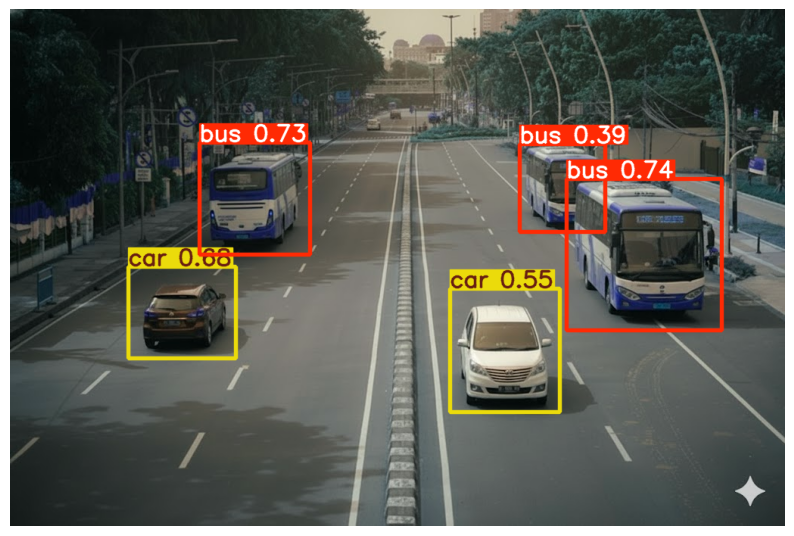

In [81]:
import matplotlib.pyplot as plt

result = results[0]

annotated = result.plot()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(annotated)
plt.axis("off")
plt.show()